# STEP 1 — Load & Transform Dataset

## Imports

In [2]:
import nltk
import re
import numpy as np
import pandas as pd
import torch
from nltk.corpus import stopwords
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
# nltk.download('punkt')
# nltk.download('punkt_tab')
# nltk.download('stopwords')

## Parse JSON Files

In [3]:
import json
import os

def load_dataset(path):
    dataset = []
    
    for file in os.listdir(path):
        if file.endswith(".json"):
            file_path = os.path.join(path, file)
            
            with open(file_path, encoding="utf-8") as f:
                data = json.load(f)

                for article in data.get("data", []):
                    for para in article.get("paragraphs", []):
                        context = para.get("context", "")

                        for qa in para.get("qas", []):
                            question = qa.get("question", "")
                            answers = qa.get("answers", [])

                            if answers:
                                answer = answers[0].get("text", "")
                                
                                dataset.append({
                                    "question": question,
                                    "context": context,
                                    "answer": answer
                                })
    
    return dataset
    

## Inspect Data

In [4]:
data = load_dataset("data")

print(f"\nTotal examples loaded: {len(data)}")
if data:
    print("\nFirst example:")
    print(json.dumps(data[0], indent=2, ensure_ascii=False))


Total examples loaded: 240

First example:
{
  "question": "ما الحدث الذي جعل أورسون ويلز مشهورًا قبل دخوله السينما؟",
  "context": "في ليلة 30 أكتوبر 1938، انقطع بث إذاعي ليعلن عن غزو فضائي في نيوجيرسي. تسبب ذلك في ذعر واسع لأن الناس صدقوا الخبر. لاحقًا تبيّن أن الحدث كان تمثيلية إذاعية من إخراج أورسون ويلز. هذه التجربة أثبتت قدرته على التأثير في الجمهور.",
  "answer": "تمثيلية إذاعية عن غزو فضائي"
}


# STEP 2 — Preprocessing

## Cleaning

In [5]:
# def remove_stopwords_and_punctuation_from_text(text):
#     nltk_stop_words = set(stopwords.words('arabic'))


#     # punctuation ='!"$%&()*,-./:;<=>?@[\\]^_`{|}~'
#     punctuation = [
#     "،","؛","؟","ـ","«","»","‹","›","“","”","‘","’",
#     ".",",",";",":","!","?","-","_","(",")","[","]","{","}",
#     "\"","'","/","\\","|","@","#","$","%","^","&","*","+","=","<",">","~","`","``","''"
#     ]
#     for p in punctuation:
#         text = text.replace(p, '')

#     tokens = nltk.word_tokenize(text)

#     filtered_tokens = [
#         word for word in tokens 
#         if word not in nltk_stop_words 
#         and not re.search(r'[a-zA-Z]', word)]   # remove words containing English letters
#     # Join the tokens back into a string
#     filtered_text = ' '.join(filtered_tokens)
#     return filtered_text

In [6]:
# for item in data:
#     item['question'] = remove_stopwords_and_punctuation_from_text(item['question'])
#     item['context'] = remove_stopwords_and_punctuation_from_text(item['context'])
#     item['answer'] = remove_stopwords_and_punctuation_from_text(item['answer'])

## Normalization

In [7]:
import re

def normalize_text(text):
    
    # 1. Convert English letters to lowercase
    text = text.lower()
    
    # 2. Remove Arabic Tashkeel (diacritics)
    tashkeel = r'[\u0617-\u061A\u064B-\u0652]'
    text = re.sub(tashkeel, '', text)

    # 3. Normalize Arabic letters
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ة", "ه", text)
    text = re.sub("گ", "ك", text)

    # 4. Remove Tatweel (ـ)
    text = re.sub("ـ", "", text)

    return text

In [8]:
for item in data:
    item['question'] = normalize_text(item['question'])
    item['context'] = normalize_text(item['context'])
    item['answer'] = normalize_text(item['answer'])

# STEP 3 — Tokenization

## Tokenize

### Approach 1

In [9]:
# def tokenize(text):
#     return text.split()

### Approach 2

In [10]:
tokenizer = Tokenizer(
    num_words=2390,
    split=' ',
    char_level=False,
    oov_token="<OOV>"
  )

In [11]:
all_texts = []

for item in data:
    all_texts.append(item['question'])
    all_texts.append(item['context'])
    all_texts.append(item['answer'])

all_texts = [text for text in all_texts if text and isinstance(text, str)]
tokenizer.fit_on_texts(all_texts)

In [12]:
vocab_list = tokenizer.word_index
print(len(vocab_list))

2381


In [13]:
# lengths = [len(seq) for seq in all_texts]
# print("answer_sequences lengths:")
# print("max:", np.max(lengths))
# print("min:", np.min(lengths))
# print("95 percentile:", np.percentile(lengths,95))
# print("90 percentile:", np.percentile(lengths,90))

In [14]:
max_length = 125

## Encode Text

### Approach 1

In [15]:
# def encode(text, vocab, max_len=100):
#     tokens = tokenize(text)
#     ids = [vocab.get(t, vocab["<unk>"]) for t in tokens]

#     # padding
#     ids = ids[:max_len]
#     ids += [vocab["<pad>"]] * (max_len - len(ids))

#     return ids

In [16]:
# ### Encode the dataset with answers also encoded
# encoded_data = []
# for item in data:
#     encoded_item = {
#         "question": encode(item["question"], vocab),
#         "context": encode(item["context"], vocab),
#         "answer": encode(item["answer"], vocab)
#     }
#     encoded_data.append(encoded_item)


### Approach 2

In [17]:
# max_question_len = 0
# max_context_len = 0
# max_answer_len = 0

# for item in data:
#     q_tokens = len(tokenizer.texts_to_sequences([item['question']])[0]) if 'question' in item else 0
#     c_tokens = len(tokenizer.texts_to_sequences([item['context']])[0])  if 'context' in item else 0
#     a_tokens = len(tokenizer.texts_to_sequences([item['answer']])[0])    if 'answer' in item else 0
    
#     max_question_len = max(max_question_len, q_tokens)
#     max_context_len  = max(max_context_len, c_tokens)
#     max_answer_len   = max(max_answer_len, a_tokens)

# print(f"Maximum Question Length: {max_question_len} tokens")
# print(f"Maximum Context Length : {max_context_len} tokens")
# print(f"Maximum Answer Length  : {max_answer_len} tokens")

In [18]:
lengths = [len(item['question']) for item in data]
print("input_sequences lengths:")
print("max:", np.max(lengths))
print("min:", np.min(lengths))
print("95 percentile:", np.percentile(lengths,95))
print("90 percentile:", np.percentile(lengths,90))

lengths = [len(item['answer']) for item in data]
print("answer_sequences lengths:")
print("max:", np.max(lengths))
print("min:", np.min(lengths))
print("95 percentile:", np.percentile(lengths,95))
print("90 percentile:", np.percentile(lengths,90))

lengths = [len(item['context']) for item in data]
print("context_sequences lengths:")
print("max:", np.max(lengths))
print("min:", np.min(lengths))
print("95 percentile:", np.percentile(lengths,95))
print("90 percentile:", np.percentile(lengths,90))

input_sequences lengths:
max: 73
min: 14
95 percentile: 59.0
90 percentile: 54.099999999999994
answer_sequences lengths:
max: 66
min: 4
95 percentile: 50.0
90 percentile: 45.0
context_sequences lengths:
max: 261
min: 16
95 percentile: 169.04999999999998
90 percentile: 135.2


In [19]:
MAX_Q_LEN = 100
MAX_C_LEN = 200
MAX_A_LEN = 70

q_seq = []
c_seq = []
a_seq = []

for item in data:
    q_seq.append(tokenizer.texts_to_sequences([item['question']])[0])
    c_seq.append(tokenizer.texts_to_sequences([item['context']])[0])
    a_seq.append(tokenizer.texts_to_sequences([item['answer']])[0])

q_seq = pad_sequences(q_seq, maxlen=MAX_Q_LEN, padding='post')
c_seq = pad_sequences(c_seq, maxlen=MAX_C_LEN, padding='post')
a_seq = pad_sequences(a_seq, maxlen=MAX_A_LEN, padding='post')

In [20]:
max(len(seq) for seq in a_seq)

70

## Build Vocabulary

### Approach 1

In [21]:
# from collections import Counter

# def build_vocab(data, min_freq=2):
#     counter = Counter()

#     for item in data:
#         counter.update(tokenize(item["question"]))
#         counter.update(tokenize(item["context"]))

#     vocab = {"<pad>": 0, "<unk>": 1}

#     for word, freq in counter.items():
#         if freq >= min_freq:
#             vocab[word] = len(vocab)

#     return vocab

In [22]:
# vocab = build_vocab(data)
# print(f"Vocabulary size: {len(vocab)}")

### Approach 2

In [23]:
# use this to get insight on the Tokenizer
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1

## PyTorch Dataset

In [24]:
q_tensor = torch.tensor(q_seq)
c_tensor = torch.tensor(c_seq)
a_tensor = torch.tensor(a_seq)

In [25]:
from torch.utils.data import Dataset

class QADataset(Dataset):
    def __init__(self, q, c, a):
        self.q = q
        self.c = c
        self.a = a

    def __len__(self):
        return len(self.q)

    def __getitem__(self, idx):
        return self.q[idx], self.c[idx], self.a[idx]

## DataLoader

In [26]:
from torch.utils.data import DataLoader

dataset = QADataset(q_tensor, c_tensor, a_tensor)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

## Model 1: Bi-LSTM

In [27]:
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Bidirectional, Dropout
# Model Definition with biLSTM Kera Sequential model

embedding_dim = 64 # size of the vector used to represent each word
units = 128 # number of units in the LSTM layer

# Inputs
question_input = Input(shape=(MAX_Q_LEN,), name="question_input")
context_input = Input(shape=(MAX_C_LEN,), name="context_input")

# Shared embedding (important!)
embedding = Embedding(vocab_size, embedding_dim, mask_zero=True)

# Embed both
q_emb = embedding(question_input)
c_emb = embedding(context_input)

# Encode
q_encoded = Bidirectional(LSTM(units))(q_emb)
c_encoded = Bidirectional(LSTM(units))(c_emb)

# Merge
merged = Concatenate()([q_encoded, c_encoded])

# Dense layers (same as yours)
x = Dropout(0.2)(merged)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(vocab_size, activation='softmax')(x)

# Model
model = Model(inputs=[question_input, context_input], outputs=output)
# Set the training parameters
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
from sklearn.preprocessing import LabelEncoder

answers = [item['answer'] for item in data]

encoder = LabelEncoder()
y = encoder.fit_transform(answers)

In [29]:
from sklearn.model_selection import train_test_split

q_train, q_test, c_train, c_test, y_train, y_test = train_test_split(
    q_seq, c_seq, y,   # your full datasets
    test_size=0.2,
    random_state=42
)

In [30]:
# Train the model
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    [q_train, c_train],   # 👈 two inputs here
    y_train,
    epochs=30,
    validation_data=([q_test, c_test], y_test),
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 248ms/step - accuracy: 0.0000e+00 - loss: 7.7748 - val_accuracy: 0.0000e+00 - val_loss: 7.7734
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.0156 - loss: 7.7576 - val_accuracy: 0.0000e+00 - val_loss: 7.7670
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.0104 - loss: 7.6885 - val_accuracy: 0.0000e+00 - val_loss: 7.7263
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - accuracy: 0.0104 - loss: 7.1295 - val_accuracy: 0.0000e+00 - val_loss: 7.9647
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - accuracy: 0.0000e+00 - loss: 5.9651 - val_accuracy: 0.0000e+00 - val_loss: 10.3240
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - accuracy: 0.0052 - loss: 5.5199 - val_accuracy: 0.0000e+00 - val_loss: 9.2270
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.0052 - loss: 5.3007 - val_accuracy: 0.0000e+00 - val_loss: 8.8847


## Training Visualization
Plot training and validation loss/accuracy from the model history.

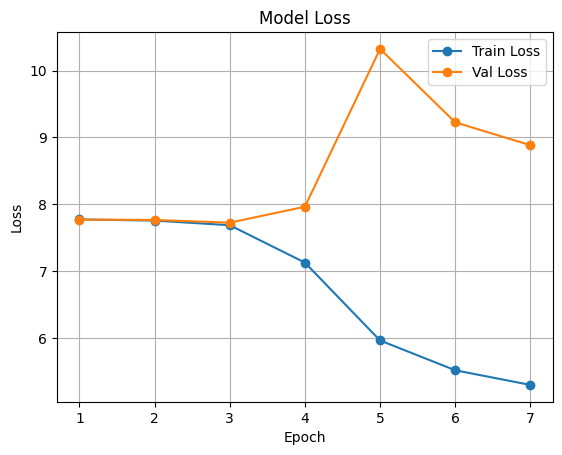

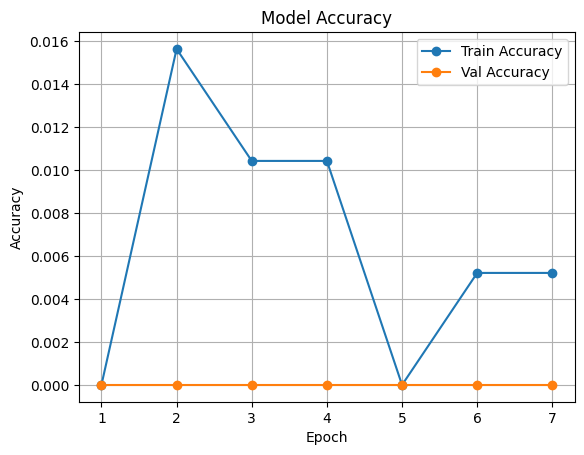

In [31]:
%matplotlib inline
import matplotlib.pyplot as plt

hist = history.history

train_loss = hist['loss']
val_loss = hist.get('val_loss', [])
train_acc = hist['accuracy']
val_acc = hist.get('val_accuracy', [])

epochs = range(1, len(train_loss) + 1)

# -------- Loss --------
plt.figure()
plt.plot(epochs, train_loss, marker='o', label='Train Loss')
if val_loss:
    plt.plot(epochs, val_loss, marker='o', label='Val Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

# -------- Accuracy --------
plt.figure()
plt.plot(epochs, train_acc, marker='o', label='Train Accuracy')
if val_acc:
    plt.plot(epochs, val_acc, marker='o', label='Val Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

## Inference Example
Try the model on one example context and question, then print the predicted answer.

In [ ]:
import json
import os

# دالة الاستدلال: تستقبل سؤالاً وسياقاً وتعيد الإجابة المتوقعة
def predict_answer(question, context):
    if 'model' not in globals() or 'tokenizer' not in globals() or 'encoder' not in globals():
        print("يرجى تشغيل خلايا التدريب (model/tokenizer/encoder) أولاً.")
        return None

    if not question or not context:
        print("السؤال أو السياق فارغ.")
        return None

    question_clean = normalize_text(question)
    context_clean = normalize_text(context)

    question_encoded = tokenizer.texts_to_sequences([question_clean])
    context_encoded = tokenizer.texts_to_sequences([context_clean])

    question_padded = pad_sequences(question_encoded, maxlen=MAX_Q_LEN, padding='post')
    context_padded = pad_sequences(context_encoded, maxlen=MAX_C_LEN, padding='post')

    probabilities = model.predict([question_padded, context_padded], verbose=0)
    predicted_index = int(np.argmax(probabilities, axis=1)[0])
    predicted_answer = encoder.inverse_transform([predicted_index])[0]

    return predicted_answer


def get_arabic_example_from_file(file_path='data/citizen_kane_qa_dataset.json'):
    try:
        with open(file_path, encoding='utf-8') as f:
            content = json.load(f)

        paragraph = content['data'][0]['paragraphs'][0]
        context = paragraph['context']
        question = paragraph['qas'][0]['question']
        answer = paragraph['qas'][0]['answers'][0]['text']
        return context, question, answer
    except Exception as e:
        print('تعذر تحميل مثال من الملف:', e)
        return None, None, None


# Example inference from the same dataset
sample_context, sample_question, ground_truth_answer = get_arabic_example_from_file()

if sample_context is None or sample_question is None:
    sample_context = 'في ليلة 30 أكتوبر 1938، انقطع بث إذاعي ليعلن عن غزو فضائي في نيوجيرسي. تسبب ذلك في ذعر واسع لأن الناس صدقوا الخبر. لاحقًا تبيّن أن الحدث كان تمثيلية إذاعية من إخراج أورسون ويلز. هذه التجربة أثبتت قدرته على التأثير في الجمهور.'
    sample_question = 'ما الحدث الذي جعل أورسون ويلز مشهورًا قبل دخوله السينما؟'
    ground_truth_answer = None

predicted_answer = predict_answer(sample_question, sample_context)

print('السؤال:', sample_question)
print('السياق:', sample_context)
if ground_truth_answer is not None:
    print('الإجابة الحقيقية:', ground_truth_answer)
print('الإجابة المتوقعة:', predicted_answer)

السؤال: ما الحدث الذي جعل أورسون ويلز مشهورًا قبل دخوله السينما؟
السياق: في ليلة 30 أكتوبر 1938، انقطع بث إذاعي ليعلن عن غزو فضائي في نيوجيرسي. تسبب ذلك في ذعر واسع لأن الناس صدقوا الخبر. لاحقًا تبيّن أن الحدث كان تمثيلية إذاعية من إخراج أورسون ويلز. هذه التجربة أثبتت قدرته على التأثير في الجمهور.
الإجابة المتوقعة: في حجم كره جولف


# Approach two

In [33]:
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Bidirectional, Dropout
from tensorflow.keras.layers import RepeatVector
from tensorflow.keras.layers import Lambda
# Model Definition with biLSTM Kera Sequential model

embedding_dim = 64 # size of the vector used to represent each word
units = 64 # number of units in the LSTM layer

# Inputs
question_input = Input(shape=(MAX_Q_LEN,), name="question_input")
context_input = Input(shape=(MAX_C_LEN,), name="context_input")

# Shared embedding (important!)
embedding = Embedding(vocab_size, embedding_dim, mask_zero=True)

# Embed both
q_emb = embedding(question_input)
c_emb = embedding(context_input)

# Encode
q_encoded = Bidirectional(LSTM(units))(q_emb)
c_encoded = Bidirectional(LSTM(units, return_sequences=True))(c_emb)

# Merge

q_repeated = RepeatVector(MAX_C_LEN)(q_encoded)

merged = Concatenate()([c_encoded, q_repeated])

# Dense layers (same as yours)
x = Dropout(0.2)(merged)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)
start_output = Dense(1)(x)
end_output   = Dense(1)(x)

start_output = Lambda(lambda x: tf.squeeze(x, axis=-1))(start_output)
end_output   = Lambda(lambda x: tf.squeeze(x, axis=-1))(end_output)

start_output = tf.keras.layers.Activation('softmax', name='start')(start_output)
end_output   = tf.keras.layers.Activation('softmax', name='end')(end_output)
# Model
model = Model(inputs=[question_input, context_input], outputs=[start_output, end_output])
# Set the training parameters
model.compile(
    optimizer='adam',
    loss={
        'start': 'sparse_categorical_crossentropy',
        'end': 'sparse_categorical_crossentropy'
    },
    metrics={
        'start': 'accuracy',
        'end': 'accuracy'
    }
)

c:\backup\guc\10th sem\nlp\NLP-Project\.venv\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'lambda' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
c:\backup\guc\10th sem\nlp\NLP-Project\.venv\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'lambda_1' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [34]:
# from sklearn.preprocessing import LabelEncoder

# answers = [item['answer'] for item in data]

# encoder = LabelEncoder()
# y = encoder.fit_transform(answers)

In [35]:
def find_span(context_seq, answer_seq):
    answer_seq = [t for t in answer_seq if t != 0]  # remove padding

    for i in range(len(context_seq)):
        if context_seq[i:i+len(answer_seq)] == answer_seq:
            return i, i + len(answer_seq) - 1

    return 0, 0  # fallback if not found

In [36]:
y_start = []
y_end = []

for c, a in zip(c_seq, a_seq):  # a_seq MUST exist from preprocessing
    s, e = find_span(list(c), list(a))
    y_start.append(s)
    y_end.append(e)

y_start = np.array(y_start)
y_end   = np.array(y_end)

In [37]:
from sklearn.model_selection import train_test_split

q_train, q_test, c_train, c_test, y_start_train, y_start_test, y_end_train, y_end_test = train_test_split(
    q_seq, c_seq, y_start, y_end,   # your full datasets
    test_size=0.2,
    random_state=42
)

In [38]:
# Train the model
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    [q_train, c_train],   # 👈 two inputs here
    [y_start_train, y_end_train],   # 👈 two outputs here
    epochs=30,
    validation_data=([q_test, c_test], [y_start_test, y_end_test]),
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - end_accuracy: 0.0573 - end_loss: 5.2879 - loss: 10.5803 - start_accuracy: 0.0573 - start_loss: 5.2924 - val_end_accuracy: 0.0625 - val_end_loss: 5.2656 - val_loss: 10.5372 - val_start_accuracy: 0.1042 - val_start_loss: 5.2721
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - end_accuracy: 0.0885 - end_loss: 5.2178 - loss: 10.4556 - start_accuracy: 0.0781 - start_loss: 5.2379 - val_end_accuracy: 0.0208 - val_end_loss: 5.1333 - val_loss: 10.2910 - val_start_accuracy: 0.0833 - val_start_loss: 5.1628
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - end_accuracy: 0.0990 - end_loss: 4.9615 - loss: 9.9929 - start_accuracy: 0.1667 - start_loss: 5.0314 - val_end_accuracy: 0.0417 - val_end_loss: 4.6513 - val_loss: 9.4253 - val_start_accuracy: 0.1250 - val_start_loss: 4.8004
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - end_accuracy: 0.1615 - end_loss: 4.0511 - loss: 8.3824 - start_accuracy: 0.1771 - start_loss: 4.3314 - val_end_accuracy

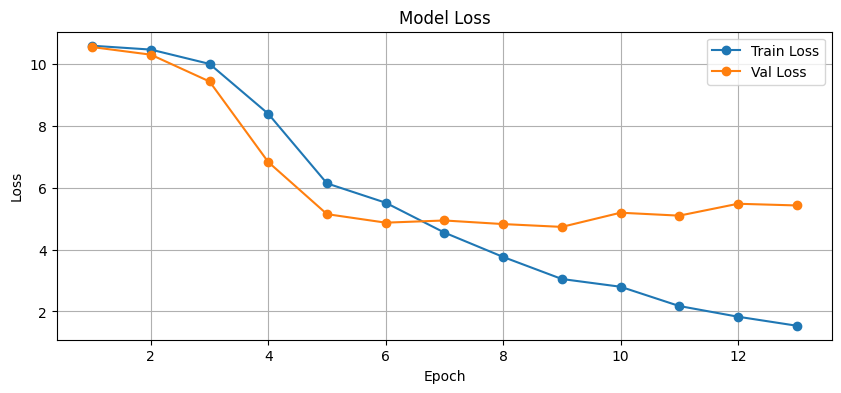

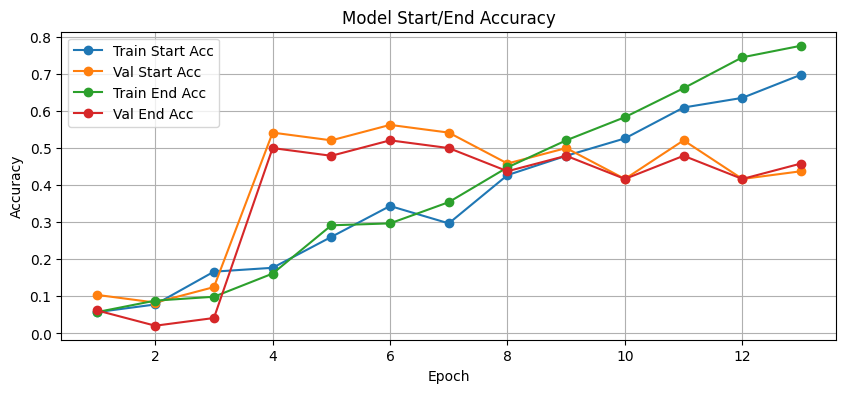

In [39]:
%matplotlib inline
import matplotlib.pyplot as plt

hist = history.history

train_loss = hist.get('loss', [])
val_loss = hist.get('val_loss', [])
train_acc_start = hist.get('start_accuracy', [])
train_acc_end = hist.get('end_accuracy', [])
val_acc_start = hist.get('val_start_accuracy', [])
val_acc_end = hist.get('val_end_accuracy', [])

epochs = range(1, len(train_loss) + 1)

# -------- Loss --------
plt.figure(figsize=(10, 4))
if train_loss:
    plt.plot(epochs, train_loss, marker='o', label='Train Loss')
if val_loss:
    plt.plot(epochs, val_loss, marker='o', label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# -------- Accuracy (Start/End) --------
plt.figure(figsize=(10, 4))
if train_acc_start:
    plt.plot(epochs, train_acc_start, marker='o', label='Train Start Acc')
if val_acc_start:
    plt.plot(epochs, val_acc_start, marker='o', label='Val Start Acc')
if train_acc_end:
    plt.plot(epochs, train_acc_end, marker='o', label='Train End Acc')
if val_acc_end:
    plt.plot(epochs, val_acc_end, marker='o', label='Val End Acc')
plt.title('Model Start/End Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [45]:
import json
import os
import random

def predict_answer(question, context):
    """
    Predict answer span using start/end position probabilities.
    Args:
        question: Question text
        context: Context/passage text
    Returns:
        Predicted answer span
    """
    if 'model' not in globals() or 'tokenizer' not in globals():
        print("يرجى تشغيل خلايا التدريب (model/tokenizer) أولاً.")
        return None

    if not question or not context:
        print("السؤال أو السياق فارغ.")
        return None

    question_clean = normalize_text(question)
    context_clean = normalize_text(context)

    question_encoded = tokenizer.texts_to_sequences([question_clean])
    context_encoded = tokenizer.texts_to_sequences([context_clean])

    question_padded = pad_sequences(question_encoded, maxlen=MAX_Q_LEN, padding='post')
    context_padded = pad_sequences(context_encoded, maxlen=MAX_C_LEN, padding='post')

    # Get probability distributions over positions
    start_probs, end_probs = model.predict([question_padded, context_padded], verbose=0)
    
    # Extract argmax positions and confidence
    start_idx = int(np.argmax(start_probs[0]))
    end_idx = int(np.argmax(end_probs[0]))
    start_conf = float(np.max(start_probs[0]))
    end_conf = float(np.max(end_probs[0]))

    # Ensure valid span (end >= start)
    if end_idx < start_idx:
        end_idx = start_idx

    # Decode to text
    context_tokens = context_clean.split()
    # if not context_tokens:
    #     return ("" , 0.0) if return_confidence else ""

    # Clamp to valid range
    start_idx = max(0, min(start_idx, len(context_tokens) - 1))
    end_idx = max(start_idx, min(end_idx, len(context_tokens) - 1))

    predicted_span = " ".join(context_tokens[start_idx:end_idx + 1]).strip()
    
    return predicted_span


# Test with random example from dataset
idx = random.randint(0, len(data) - 1)
sample_item = data[idx]
sample_question = sample_item['question']
sample_context = sample_item['context']
ground_truth_answer = sample_item['answer']

predicted_answer = predict_answer(sample_question, sample_context)

print(f'📌 Example #{idx + 1} from dataset:')
print(f'\n❓ Question: {sample_question}')
print(f'\n📝 Context: {sample_context}')
print(f'\n✅ Ground Truth: {ground_truth_answer}')
print(f'\n🤖 Prediction: {predicted_answer}')
# print(f'\n📊 Confidence: {confidence:.2%}')

📌 Example #130 from dataset:

❓ Question: ماذا يحدث عند الاستمرار في تقسيم المسافه الي اجزاء اصغر؟

📝 Context: تعتمد مفارقه زينون علي فكره تقسيم المسافه. كل خطوه تتطلب قطع جزء اصغر من السابق. ومع الاستمرار في هذا التقسيم، هنفضل ننصص الي ما لانهايه.

✅ Ground Truth: هنفضل ننصص الي ما لانهايه

🤖 Prediction: ما لانهايه.
